In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("GPU available:", torch.cuda.is_available())

transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

print("Data ready")

GPU available: True


100%|██████████| 170M/170M [34:12<00:00, 83.1kB/s] 


Data ready


In [2]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 32x32 -> 16x16
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 16x16 -> 8x8
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2), nn.ReLU(),  # 8x8 -> 16x16
            nn.ConvTranspose2d(64, 32, 2, stride=2), nn.ReLU(),   # 16x16 -> 32x32
            nn.Conv2d(32, 3, 3, padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

def add_noise(images, noise_level):
    noise = torch.randn_like(images) * noise_level
    noisy = images + noise
    return torch.clamp(noisy, 0, 1)

model_ae = DenoisingAutoencoder().to(device)
print(model_ae)

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Sigmoid()
  )
)


In [3]:
criterion_ae = nn.MSELoss()
optimizer_ae = optim.Adam(model_ae.parameters(), lr=0.001)

noise_level_train = 0.2

for epoch in range(15):
    model_ae.train()
    running_loss = 0.0
    for images, _ in trainloader:
        images = images.to(device)
        noisy_images = add_noise(images, noise_level_train)

        optimizer_ae.zero_grad()
        outputs = model_ae(noisy_images)
        loss = criterion_ae(outputs, images)
        loss.backward()
        optimizer_ae.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/15, Loss: {running_loss/len(trainloader):.4f}")

Epoch 1/15, Loss: 0.0140
Epoch 2/15, Loss: 0.0073
Epoch 3/15, Loss: 0.0067
Epoch 4/15, Loss: 0.0059
Epoch 5/15, Loss: 0.0056
Epoch 6/15, Loss: 0.0054
Epoch 7/15, Loss: 0.0052
Epoch 8/15, Loss: 0.0051
Epoch 9/15, Loss: 0.0049
Epoch 10/15, Loss: 0.0048
Epoch 11/15, Loss: 0.0047
Epoch 12/15, Loss: 0.0046
Epoch 13/15, Loss: 0.0046
Epoch 14/15, Loss: 0.0045
Epoch 15/15, Loss: 0.0045


In [4]:
model_ae_v2 = DenoisingAutoencoder().to(device)
criterion_ae = nn.MSELoss()
optimizer_ae = optim.Adam(model_ae_v2.parameters(), lr=0.001)

for epoch in range(15):
    model_ae_v2.train()
    running_loss = 0.0
    for images, _ in trainloader:
        images = images.to(device)
        noise_level = torch.empty(1).uniform_(0.1, 0.3).item()
        noisy_images = add_noise(images, noise_level)

        optimizer_ae.zero_grad()
        outputs = model_ae_v2(noisy_images)
        loss = criterion_ae(outputs, images)
        loss.backward()
        optimizer_ae.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/15, Loss: {running_loss/len(trainloader):.4f}")

Epoch 1/15, Loss: 0.0163
Epoch 2/15, Loss: 0.0077
Epoch 3/15, Loss: 0.0070
Epoch 4/15, Loss: 0.0063
Epoch 5/15, Loss: 0.0059
Epoch 6/15, Loss: 0.0056
Epoch 7/15, Loss: 0.0054
Epoch 8/15, Loss: 0.0051
Epoch 9/15, Loss: 0.0051
Epoch 10/15, Loss: 0.0050
Epoch 11/15, Loss: 0.0050
Epoch 12/15, Loss: 0.0049
Epoch 13/15, Loss: 0.0048
Epoch 14/15, Loss: 0.0048
Epoch 15/15, Loss: 0.0047


In [5]:
def psnr(mse):
    if mse == 0:
        return 100
    return 10 * torch.log10(1.0 / mse).item()

model_ae_v2.eval()
noise_levels_test = [0.1, 0.2, 0.3, 0.4]
results = {}

with torch.no_grad():
    for nl in noise_levels_test:
        total_mse = 0
        count = 0
        for images, _ in testloader:
            images = images.to(device)
            noisy = add_noise(images, nl)
            outputs = model_ae_v2(noisy)
            mse = nn.functional.mse_loss(outputs, images).item()
            total_mse += mse
            count += 1
        avg_mse = total_mse / count
        results[nl] = psnr(torch.tensor(avg_mse))
        print(f"Noise level {nl}: MSE={avg_mse:.4f}, PSNR={results[nl]:.2f} dB")

Noise level 0.1: MSE=0.0030, PSNR=25.27 dB
Noise level 0.2: MSE=0.0044, PSNR=23.61 dB
Noise level 0.3: MSE=0.0065, PSNR=21.87 dB
Noise level 0.4: MSE=0.0094, PSNR=20.27 dB


In [6]:
!pip install scikit-image -q

from skimage.metrics import structural_similarity as ssim
import numpy as np

model_ae_v2.eval()
ssim_results = {}

with torch.no_grad():
    for nl in noise_levels_test:
        total_ssim = 0
        count = 0
        for images, _ in testloader:
            images = images.to(device)
            noisy = add_noise(images, nl)
            outputs = model_ae_v2(noisy)

            outputs_np = outputs.cpu().numpy()
            images_np = images.cpu().numpy()
            for i in range(outputs_np.shape[0]):
                s = ssim(images_np[i].transpose(1,2,0), outputs_np[i].transpose(1,2,0),
                          channel_axis=2, data_range=1.0)
                total_ssim += s
                count += 1
        avg_ssim = total_ssim / count
        ssim_results[nl] = avg_ssim
        print(f"Noise level {nl}: SSIM={avg_ssim:.4f}")

Noise level 0.1: SSIM=0.8558
Noise level 0.2: SSIM=0.7952
Noise level 0.3: SSIM=0.7193
Noise level 0.4: SSIM=0.6425


In [7]:
from scipy.ndimage import gaussian_filter, median_filter

def classical_denoise_psnr_ssim(noise_level, method='gaussian'):
    total_mse = 0
    total_ssim = 0
    count = 0
    for images, _ in testloader:
        images_np = images.numpy()
        noisy_np = np.clip(images_np + np.random.randn(*images_np.shape) * noise_level, 0, 1)

        denoised = np.zeros_like(noisy_np)
        for i in range(noisy_np.shape[0]):
            for c in range(3):
                if method == 'gaussian':
                    denoised[i, c] = gaussian_filter(noisy_np[i, c], sigma=1)
                elif method == 'median':
                    denoised[i, c] = median_filter(noisy_np[i, c], size=3)

        mse = np.mean((denoised - images_np) ** 2)
        total_mse += mse
        for i in range(noisy_np.shape[0]):
            s = ssim(images_np[i].transpose(1,2,0), denoised[i].transpose(1,2,0),
                      channel_axis=2, data_range=1.0)
            total_ssim += s
            count += 1

    avg_mse = total_mse / len(testloader)
    avg_ssim = total_ssim / count
    avg_psnr = 10 * np.log10(1.0 / avg_mse) if avg_mse > 0 else 100
    return avg_psnr, avg_ssim

print("Gaussian blur baseline:")
for nl in noise_levels_test:
    p, s = classical_denoise_psnr_ssim(nl, method='gaussian')
    print(f"Noise {nl}: PSNR={p:.2f} dB, SSIM={s:.4f}")

print("\nMedian filter baseline:")
for nl in noise_levels_test:
    p, s = classical_denoise_psnr_ssim(nl, method='median')
    print(f"Noise {nl}: PSNR={p:.2f} dB, SSIM={s:.4f}")

Gaussian blur baseline:
Noise 0.1: PSNR=23.81 dB, SSIM=0.8059
Noise 0.2: PSNR=21.51 dB, SSIM=0.6998
Noise 0.3: PSNR=19.39 dB, SSIM=0.5972
Noise 0.4: PSNR=17.72 dB, SSIM=0.5100

Median filter baseline:
Noise 0.1: PSNR=23.54 dB, SSIM=0.7782
Noise 0.2: PSNR=20.02 dB, SSIM=0.6267
Noise 0.3: PSNR=17.40 dB, SSIM=0.5069
Noise 0.4: PSNR=15.41 dB, SSIM=0.4142


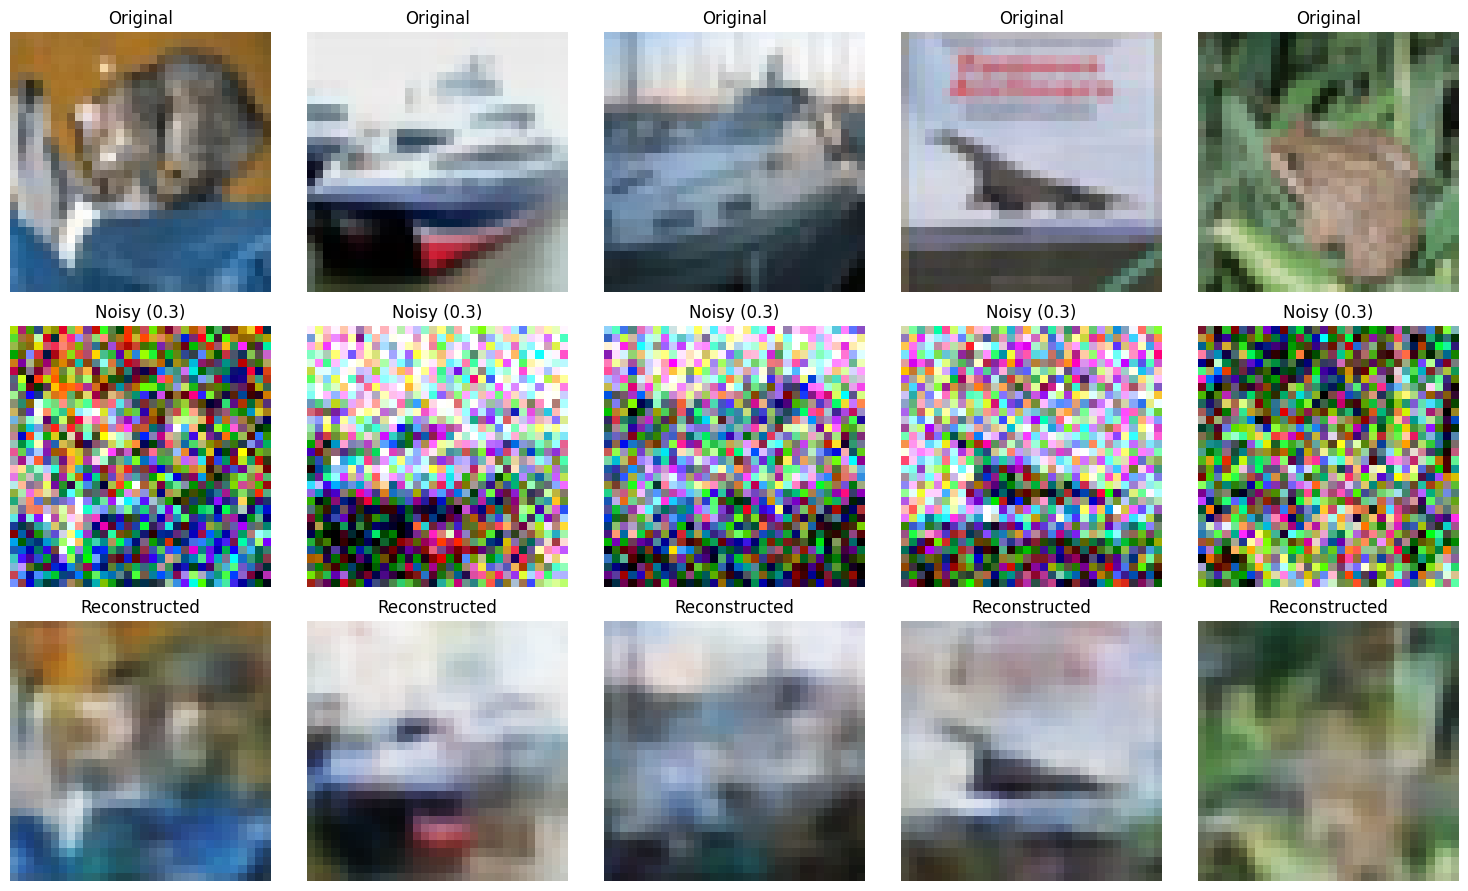

In [8]:
model_ae_v2.eval()
images, _ = next(iter(testloader))
images = images.to(device)
noisy = add_noise(images, 0.3)  # medium-heavy noise for a clear visual difference

with torch.no_grad():
    outputs = model_ae_v2(noisy)

n = 5
fig, axes = plt.subplots(3, n, figsize=(15, 9))
for i in range(n):
    axes[0, i].imshow(images[i].cpu().permute(1,2,0))
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')

    axes[1, i].imshow(noisy[i].cpu().permute(1,2,0))
    axes[1, i].set_title("Noisy (0.3)")
    axes[1, i].axis('off')

    axes[2, i].imshow(outputs[i].cpu().permute(1,2,0))
    axes[2, i].set_title("Reconstructed")
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

In [9]:
def noisy_baseline_metrics(noise_level):
    total_mse = 0
    total_ssim = 0
    count = 0
    for images, _ in testloader:
        images_np = images.numpy()
        noisy_np = np.clip(images_np + np.random.randn(*images_np.shape) * noise_level, 0, 1)
        mse = np.mean((noisy_np - images_np) ** 2)
        total_mse += mse
        for i in range(noisy_np.shape[0]):
            s = ssim(images_np[i].transpose(1,2,0), noisy_np[i].transpose(1,2,0),
                      channel_axis=2, data_range=1.0)
            total_ssim += s
            count += 1
    avg_mse = total_mse / len(testloader)
    avg_ssim = total_ssim / count
    avg_psnr = 10 * np.log10(1.0/avg_mse) if avg_mse > 0 else 100
    return avg_psnr, avg_ssim

print("Noisy input (no denoising) baseline:")
for nl in noise_levels_test:
    p, s = noisy_baseline_metrics(nl)
    print(f"Noise {nl}: PSNR={p:.2f} dB, SSIM={s:.4f}")

Noisy input (no denoising) baseline:
Noise 0.1: PSNR=20.32 dB, SSIM=0.6730
Noise 0.2: PSNR=14.78 dB, SSIM=0.4302
Noise 0.3: PSNR=11.92 dB, SSIM=0.2944
Noise 0.4: PSNR=10.22 dB, SSIM=0.2144
